<a href="https://colab.research.google.com/github/zeeshan3106/Machine-Learning/blob/main/Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [175]:
import pandas as pd
data = pd.read_csv("melbourne_coffee_preferences.csv")
data.sample(2)


,Record_ID,Gender,Age_Group,Melbourne_Suburb,Favorite_Drink,Milk_Preference,Primary_Reason_For_Choosing,Visit_Frequency,Preferred_Roast,Loyalty_Member
90,REC_091,Male,18-24,Carlton,Cappuccino,Full Cream,Friendly Baristas,Daily,Medium Roast,Yes
105,REC_106,Female,55+,Fitzroy,Long Black,Almond Milk,Pastry Selection,Weekends Only,Light Roast,Yes


In [176]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [177]:
from sklearn.preprocessing import OneHotEncoder
one = OneHotEncoder()
X_trin_transform = one.fit_transform(X_train)
X_test_transform = one.transform(X_test)
X_trin_transform

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1280 stored elements and shape (160, 41)>

In [178]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_trin_transform)
X_test_scaled = scaler.transform(X_test_transform)
X_train_scaled

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1280 stored elements and shape (160, 41)>

In [179]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=9)
model.fit(X_train_scaled,y_train)
model.predict(X_test_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,model.predict(X_test_scaled))*100

57.49999999999999

In [180]:
import numpy as np
def function(Gender,
Age_Group,
Melbourne_Suburb,
Favorite_Drink	,
Milk_Preference	,
Primary_Reason_For_Choosing,
Visit_Frequency,
Preferred_Roast):
  data=pd.DataFrame([[
    Gender, Age_Group, Melbourne_Suburb, Favorite_Drink,
    Milk_Preference, Primary_Reason_For_Choosing, Visit_Frequency, Preferred_Roast
  ]], columns=[
    'Gender', 'Age_Group', 'Melbourne_Suburb', 'Favorite_Drink',
    'Milk_Preference', 'Primary_Reason_For_Choosing', 'Visit_Frequency', 'Preferred_Roast'
  ])
  data_Trans = one.transform(data)
  data_scaled = scaler.transform(data_Trans)
  return model.predict(data_scaled)








Gender="Female"
Age_Group="45-54"
Melbourne_Suburb="Fitzroy"
Favorite_Drink="Magic"
Milk_Preference="Full Cream"
Primary_Reason_For_Choosing="Quick Service"
Visit_Frequency="Daily"
Preferred_Roast="Light Roast"


function(Gender,
Age_Group,
Melbourne_Suburb,
Favorite_Drink	,
Milk_Preference	,
Primary_Reason_For_Choosing,
Visit_Frequency,
Preferred_Roast)

array(['Yes'], dtype=object)

In [181]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train_scaled,y_train)
rf.predict(X_test_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,rf.predict(X_test_scaled))*100



57.49999999999999

In [182]:
import numpy as np
def function(Gender,
Age_Group,
Melbourne_Suburb,
Favorite_Drink	,
Milk_Preference	,
Primary_Reason_For_Choosing,
Visit_Frequency,
Preferred_Roast):
  data=pd.DataFrame([[
    Gender, Age_Group, Melbourne_Suburb, Favorite_Drink,
    Milk_Preference, Primary_Reason_For_Choosing, Visit_Frequency, Preferred_Roast
  ]], columns=[
    'Gender', 'Age_Group', 'Melbourne_Suburb', 'Favorite_Drink',
    'Milk_Preference', 'Primary_Reason_For_Choosing', 'Visit_Frequency', 'Preferred_Roast'
  ])
  data_Trans = one.transform(data)
  data_scaled = scaler.transform(data_Trans)
  return rf.predict(data_scaled)








Gender="Female"
Age_Group="45-54"
Melbourne_Suburb="Fitzroy"
Favorite_Drink="Magic"
Milk_Preference="Full Cream"
Primary_Reason_For_Choosing="Quick Service"
Visit_Frequency="Daily"
Preferred_Roast="Light Roast"


function(Gender,
Age_Group,
Melbourne_Suburb,
Favorite_Drink	,
Milk_Preference	,
Primary_Reason_For_Choosing,
Visit_Frequency,
Preferred_Roast)

array(['Yes'], dtype=object)

[Text(0.5833333333333334, 0.9, 'Melbourne_Suburb_Fitzroy <= 1.582\ngini = 0.5\nsamples = 160\nvalue = [80, 80]\nclass = No'),
 Text(0.35714285714285715, 0.7, 'Milk_Preference_Almond Milk <= 1.355\ngini = 0.498\nsamples = 142\nvalue = [75, 67]\nclass = No'),
 Text(0.47023809523809523, 0.8, 'True  '),
 Text(0.19047619047619047, 0.5, 'Melbourne_Suburb_Melbourne CBD <= 1.4\ngini = 0.5\nsamples = 119\nvalue = [59, 60]\nclass = Yes'),
 Text(0.09523809523809523, 0.3, 'Milk_Preference_Oat Milk <= 1.335\ngini = 0.497\nsamples = 96\nvalue = [44, 52]\nclass = Yes'),
 Text(0.047619047619047616, 0.1, '\n  (...)  \n'),
 Text(0.14285714285714285, 0.1, '\n  (...)  \n'),
 Text(0.2857142857142857, 0.3, 'Primary_Reason_For_Choosing_Friendly Baristas <= 1.355\ngini = 0.454\nsamples = 23\nvalue = [15, 8]\nclass = No'),
 Text(0.23809523809523808, 0.1, '\n  (...)  \n'),
 Text(0.3333333333333333, 0.1, '\n  (...)  \n'),
 Text(0.5238095238095238, 0.5, 'Favorite_Drink_Magic <= 1.452\ngini = 0.423\nsamples = 23\n

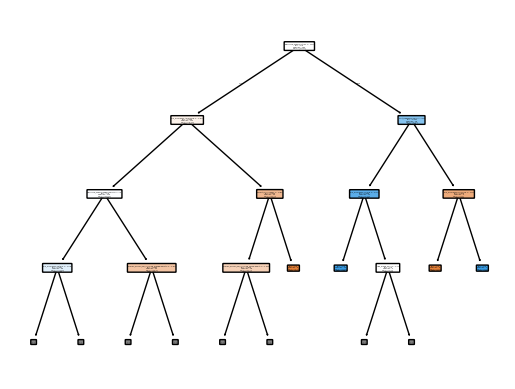

In [183]:
feature_names = one.get_feature_names_out()
feature_names
from sklearn.tree import plot_tree
plot_tree(
    model,
    feature_names=feature_names,  # Labels the splits with your columns
    class_names=['No', 'Yes'],    # Labels the final predictions
    filled=True,                  # Colors the nodes (blue for Yes, orange for No)
    rounded=True,                 # Makes the boxes look clean
    max_depth=3                   # Limits depth so it remains readable
)